# v2.8 — Bimodal Degeneracy in Carroll-6 Recovery (PR #45 analysis)

**Companion to** [`docs/findings/v2.8_darwin_ic_poc_sub.md`](../docs/findings/v2.8_darwin_ic_poc_sub.md).
**Loads** the result JSONs already in `data/legacy/scripts_json_archive/run_v2.7_multilayer_result_*.json` (no new training runs).

## Headline

v2.8 produced the project's first reproducible `scav_rat` Cal-grade recovery (7/10 Cal, 4/10 Excellent at the anchor config). The cost is that `alpfe` collapses — empirical evidence of a **bimodal degeneracy** in the (alpfe, scav_rat) loss surface where `POC_SUB_W` selects which basin the optimizer falls into.

This notebook visualises that finding across the n=10 seed runs.


In [1]:
import json
import glob
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Carroll-2022/Darwin-3 calibrated values (verified bit-identical to Carroll 2020).
CARROLL = {
    'alpfe': 0.92831, 'scav_rat': 6.0250e-7, 'Smallgrow': 0.66098,
    'Biggrow': 0.43148, 'diatomgraz': 0.83003, 'R_PICPOC': 0.04245,
}
PARAM_ORDER = list(CARROLL.keys())

# Band thresholds (from darwindiff.diagnostics.band_of):
#   Excellent if rel_off <= 0.05; Cal-grade if rel_off <= 0.40;
#   Loose if rel_off <= 0.80; Drifted otherwise.
# Locate project root robustly regardless of nbclient cwd (which is the launcher's
# cwd, not the notebook dir).
def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').is_file() and (p / 'scripts').is_dir():
            return p
    raise FileNotFoundError('project root not found')
PROJECT_ROOT = _find_project_root(Path.cwd())
SCRIPTS = PROJECT_ROOT / 'scripts'
# Don't print the absolute project path (avoids leaking local usernames into
# committed notebook outputs); print a relative confirmation instead.
print(f"project root located at {PROJECT_ROOT.name}/  (scripts/ found)")

def load_config(pattern: str, exclude_substrs=()):
    files = sorted(SCRIPTS.glob(pattern))
    files = [f for f in files if not any(s in f.name for s in exclude_substrs)]
    runs = [json.load(open(f, encoding='utf-8')) for f in files]
    return runs

print('Module imports OK; CARROLL targets loaded')
print({k: f'{v:.4g}' for k, v in CARROLL.items()})


project root located at ecco-darwindiff/  (scripts/ found)
Module imports OK; CARROLL targets loaded
{'alpfe': '0.9283', 'scav_rat': '6.025e-07', 'Smallgrow': '0.661', 'Biggrow': '0.4315', 'diatomgraz': '0.83', 'R_PICPOC': '0.04245'}


## 1. Loading the five comparison configs

All at GEOTRACES_W (surface) = 0.3, PINN_drift_w = 3.0, n = 10 seeds (8 for the two no-extra-seeds gaps).


In [2]:
configs = {
    'Lit IC (sub=0.3)':              load_config(
        'run_v2.7_multilayer_result_seed*_surf0.3_sub0.3_pinn3.0.json',
        exclude_substrs=('darwinic', 'pocsub')),
    'Darwin IC (sub=0.3, wide L2)':  load_config(
        'run_v2.7_multilayer_result_seed*_surf0.3_sub0.3_pinn3.0_darwinic.json',
        exclude_substrs=('narrowL2', 'pocsub')),
    'Darwin IC (sub=0.3, narrow L2)': load_config(
        'run_v2.7_multilayer_result_seed*_surf0.3_sub0.3_pinn3.0_darwinic_narrowL2.json'),
    'Darwin IC (sub=1.0)':           load_config(
        'run_v2.7_multilayer_result_seed*_surf0.3_sub1.0_pinn3.0_darwinic.json',
        exclude_substrs=('pocsub',)),
    'Darwin IC (sub=2.0)':           load_config(
        'run_v2.7_multilayer_result_seed*_surf0.3_sub2.0_pinn3.0_darwinic.json'),
    'v2.8: + POC_SUB=0.3':           load_config(
        'run_v2.7_multilayer_result_seed*_surf0.3_sub1.0_pinn3.0_darwinic_pocsubW0.3.json'),
    'v2.8: + POC_SUB=1.0':           load_config(
        'run_v2.7_multilayer_result_seed*_surf0.3_sub1.0_pinn3.0_darwinic_pocsubW1.0.json'),
    'v2.8: + POC_SUB=3.0 (anchor)':  load_config(
        'run_v2.7_multilayer_result_seed*_surf0.3_sub1.0_pinn3.0_darwinic_pocsubW3.0.json'),
}

for name, runs in configs.items():
    print(f'{name:<40} n={len(runs)}')


Lit IC (sub=0.3)                         n=10
Darwin IC (sub=0.3, wide L2)             n=10
Darwin IC (sub=0.3, narrow L2)           n=10
Darwin IC (sub=1.0)                      n=10
Darwin IC (sub=2.0)                      n=10
v2.8: + POC_SUB=0.3                      n=10
v2.8: + POC_SUB=1.0                      n=10
v2.8: + POC_SUB=3.0 (anchor)             n=10


## 2. Aggregate scoreboard

Mean recovery + Cal/Excellent hit counts across n=10 seeds per config.


In [3]:
def aggregate(runs):
    out = {}
    for p in PARAM_ORDER:
        vals = np.array([r['params'][p]['recovered'] for r in runs])
        rels = np.array([r['params'][p]['abs_rel_offset'] for r in runs])
        out[p] = {
            'mean': vals.mean(), 'std': vals.std(),
            'mean_off': rels.mean(),
            'cal': int((rels <= 0.40).sum()),
            'exc': int((rels <= 0.05).sum()),
            'n': len(runs),
        }
    cgs = [r['n_cal_grade'] for r in runs]
    out['aggregate_4plus'] = sum(1 for x in cgs if x >= 4)
    out['aggregate_n'] = len(runs)
    return out

# Build a long-form table
import pandas as pd
rows = []
for name, runs in configs.items():
    agg = aggregate(runs)
    for p in PARAM_ORDER:
        d = agg[p]
        rows.append({
            'config': name, 'param': p,
            'mean': d['mean'], 'std': d['std'],
            'mean_off': d['mean_off'],
            'cal_hits': f"{d['cal']}/{d['n']}",
            'exc_hits': f"{d['exc']}/{d['n']}",
        })
df = pd.DataFrame(rows)
# Pivot for scav_rat + alpfe summary (the two parameters in the degeneracy)
focus = df[df['param'].isin(['alpfe', 'scav_rat'])].copy()
focus['mean_off'] = focus['mean_off'].round(3)
focus.pivot(index='config', columns='param', values=['mean_off', 'cal_hits', 'exc_hits'])


mean_off          cal_hits          exc_hits  \
param                             alpfe scav_rat    alpfe scav_rat    alpfe   
config                                                                        
Darwin IC (sub=0.3, narrow L2)     0.26    0.947    10/10     0/10     1/10   
Darwin IC (sub=0.3, wide L2)      0.087    0.802    10/10     0/10     4/10   
Darwin IC (sub=1.0)               0.035    0.762    10/10     0/10     7/10   
Darwin IC (sub=2.0)               0.051     0.75    10/10     0/10     5/10   
Lit IC (sub=0.3)                   0.35    0.914     8/10     0/10     0/10   
v2.8: + POC_SUB=0.3               0.132    0.677     9/10     1/10     4/10   
v2.8: + POC_SUB=1.0               0.135    0.578     9/10     2/10     4/10   
v2.8: + POC_SUB=3.0 (anchor)      0.638    0.403     2/10     7/10     0/10   

                                         
param                          scav_rat  
config                                   
Darwin IC (sub=0.3, narrow L2)     0/10  
Darwin IC (sub=0.3, wide L2)       0/10  
Darwin IC (sub=1.0)                0/10  
Darwin IC (sub=2.0)                0/10  
Lit IC (sub=0.3)                   0/10  
v2.8: + POC_SUB=0.3                1/10  
v2.8: + POC_SUB=1.0                1/10  
v2.8: + POC_SUB=3.0 (anchor)       4/10

## 3. SUB_W sweep at Darwin IC (no POC_SUB yet)

How does `alpfe` and `scav_rat` evolve as we strengthen the L2-DFe anchoring weight?


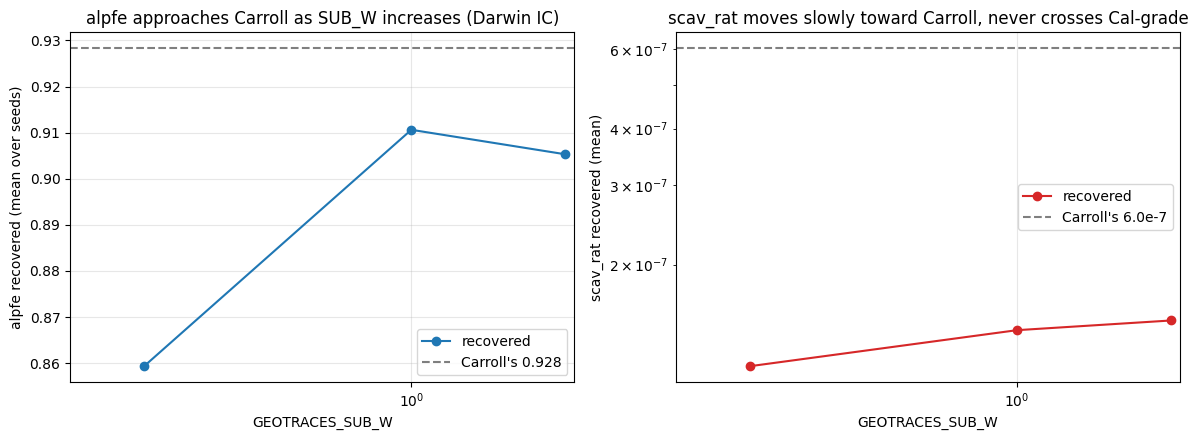

Subsurface DFe weight sweep summary (Darwin IC, no POC_SUB):
  sub=0.3    n=10  alpfe=0.859  scav_rat=1.19e-07  agg_4+=2/10
  sub=1.0    n=10  alpfe=0.911  scav_rat=1.43e-07  agg_4+=1/10
  sub=2.0    n=10  alpfe=0.905  scav_rat=1.50e-07  agg_4+=0/10


In [4]:
sub_w_configs = [
    ('sub=0.0', load_config('run_v2.7_multilayer_result_seed*_surf0.3_sub0.0_pinn3.0_darwinic.json',
                            exclude_substrs=('pocsub',))),
    ('sub=0.1', load_config('run_v2.7_multilayer_result_seed*_surf0.3_sub0.1_pinn3.0_darwinic.json',
                            exclude_substrs=('pocsub',))),
    ('sub=0.3', configs['Darwin IC (sub=0.3, wide L2)']),
    ('sub=0.5', load_config('run_v2.7_multilayer_result_seed*_surf0.3_sub0.5_pinn3.0_darwinic.json',
                            exclude_substrs=('pocsub',))),
    ('sub=1.0', configs['Darwin IC (sub=1.0)']),
    ('sub=2.0', configs['Darwin IC (sub=2.0)']),
]
sub_w_configs = [(name, runs) for name, runs in sub_w_configs if len(runs) > 0]

xs = []
alpfe_means, alpfe_offs, scav_means, scav_offs = [], [], [], []
for name, runs in sub_w_configs:
    sub_val = float(name.split('=')[1])
    xs.append(sub_val)
    a = aggregate(runs)
    alpfe_means.append(a['alpfe']['mean']); alpfe_offs.append(a['alpfe']['mean_off'])
    scav_means.append(a['scav_rat']['mean']); scav_offs.append(a['scav_rat']['mean_off'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(xs, alpfe_means, 'o-', color='C0', label='recovered')
ax1.axhline(CARROLL['alpfe'], color='k', linestyle='--', alpha=0.5, label="Carroll's 0.928")
ax1.set_xlabel('GEOTRACES_SUB_W'); ax1.set_ylabel('alpfe recovered (mean over seeds)')
ax1.set_title('alpfe approaches Carroll as SUB_W increases (Darwin IC)')
ax1.set_xscale('symlog', linthresh=0.05); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(xs, scav_means, 'o-', color='C3', label='recovered')
ax2.axhline(CARROLL['scav_rat'], color='k', linestyle='--', alpha=0.5, label="Carroll's 6.0e-7")
ax2.set_xlabel('GEOTRACES_SUB_W'); ax2.set_ylabel('scav_rat recovered (mean)')
ax2.set_title('scav_rat moves slowly toward Carroll, never crosses Cal-grade')
ax2.set_xscale('symlog', linthresh=0.05); ax2.set_yscale('log'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('Subsurface DFe weight sweep summary (Darwin IC, no POC_SUB):')
for name, runs in sub_w_configs:
    a = aggregate(runs)
    print(f'  {name:<10} n={a["alpfe"]["n"]:2d}  alpfe={a["alpfe"]["mean"]:.3f}  scav_rat={a["scav_rat"]["mean"]:.2e}  agg_4+={a["aggregate_4plus"]}/{a["aggregate_n"]}')


## 4. POC_SUB_W sweep — the bimodal basin transition

This is the central v2.8 finding. As `POC_SUB_W` rises, seeds flip from the "alpfe-correct" basin into the "scav-correct" basin. A seed is "scav-correct" if its recovered scav_rat is within 50% of Carroll's 6.025e-7.


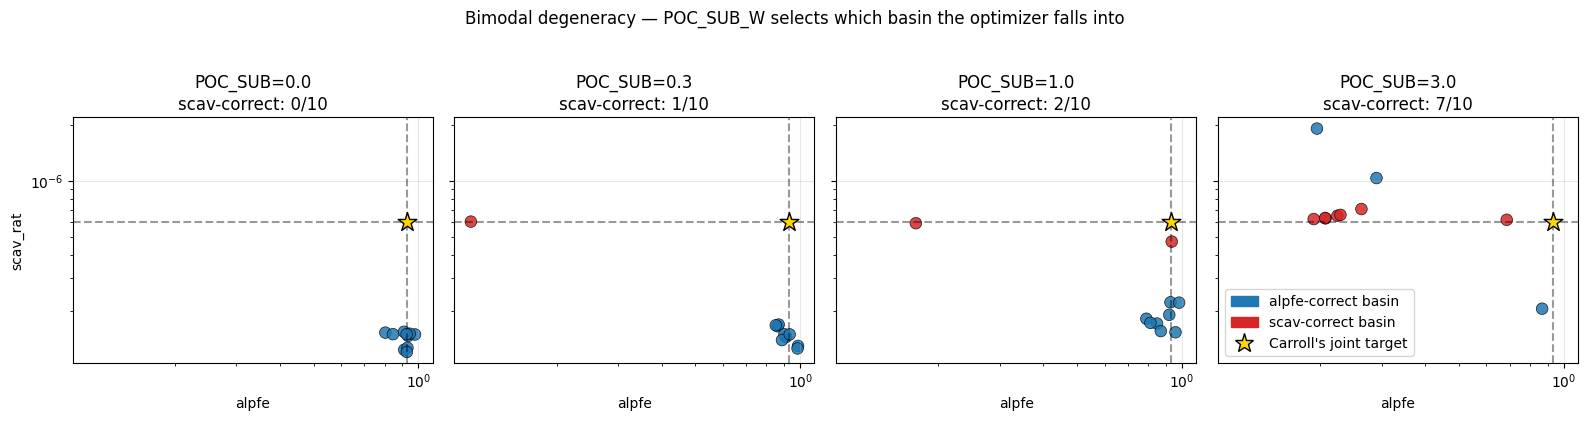

Basin distribution as POC_SUB_W rises:
  POC_SUB=0.0: alpfe-correct=10/10  scav-correct=0/10  scav_rat Exc=0  alpfe Exc=7
  POC_SUB=0.3: alpfe-correct=9/10  scav-correct=1/10  scav_rat Exc=1  alpfe Exc=4
  POC_SUB=1.0: alpfe-correct=8/10  scav-correct=2/10  scav_rat Exc=1  alpfe Exc=4
  POC_SUB=3.0: alpfe-correct=3/10  scav-correct=7/10  scav_rat Exc=4  alpfe Exc=0


In [5]:
poc_sub_configs = [
    ('POC_SUB=0.0', configs['Darwin IC (sub=1.0)']),
    ('POC_SUB=0.3', configs['v2.8: + POC_SUB=0.3']),
    ('POC_SUB=1.0', configs['v2.8: + POC_SUB=1.0']),
    ('POC_SUB=3.0', configs['v2.8: + POC_SUB=3.0 (anchor)']),
]

def basin(scav_val):
    return 'scav-correct' if abs(scav_val - CARROLL['scav_rat']) / CARROLL['scav_rat'] < 0.5 else 'alpfe-correct'

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True, sharex=True)
for ax, (name, runs) in zip(axes, poc_sub_configs):
    al = np.array([r['params']['alpfe']['recovered'] for r in runs])
    sc = np.array([r['params']['scav_rat']['recovered'] for r in runs])
    colors = ['C3' if basin(s) == 'scav-correct' else 'C0' for s in sc]
    ax.scatter(al, sc, c=colors, s=70, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.axhline(CARROLL['scav_rat'], color='k', ls='--', alpha=0.4)
    ax.axvline(CARROLL['alpfe'], color='k', ls='--', alpha=0.4)
    ax.scatter([CARROLL['alpfe']], [CARROLL['scav_rat']], marker='*', s=200, c='gold', edgecolor='black', label='Carroll', zorder=5)
    n_scav = sum(1 for s in sc if basin(s) == 'scav-correct')
    ax.set_title(f"{name}\nscav-correct: {n_scav}/{len(runs)}")
    ax.set_xlabel('alpfe'); ax.set_xscale('log'); ax.set_yscale('log')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('scav_rat')
from matplotlib.lines import Line2D
legend_elems = [
    mpatches.Patch(color='C0', label='alpfe-correct basin'),
    mpatches.Patch(color='C3', label='scav-correct basin'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold',
           markeredgecolor='black', markersize=14, label="Carroll's joint target"),
]
axes[-1].legend(handles=legend_elems, loc='lower left')
plt.suptitle('Bimodal degeneracy — POC_SUB_W selects which basin the optimizer falls into', y=1.04)
plt.tight_layout(); plt.show()

print('Basin distribution as POC_SUB_W rises:')
for name, runs in poc_sub_configs:
    n_scav = sum(1 for r in runs if basin(r['params']['scav_rat']['recovered']) == 'scav-correct')
    n_alpfe = len(runs) - n_scav
    sc_exc = sum(1 for r in runs if r['params']['scav_rat']['band'] == 'Excellent')
    al_exc = sum(1 for r in runs if r['params']['alpfe']['band'] == 'Excellent')
    print(f'  {name}: alpfe-correct={n_alpfe}/{len(runs)}  scav-correct={n_scav}/{len(runs)}  scav_rat Exc={sc_exc}  alpfe Exc={al_exc}')


## 5. Per-parameter recovery distribution at the v2.8 anchor

How wide is the n=10 distribution for each parameter at the headline (Darwin IC + sub=1.0 + POC_SUB=3.0)?


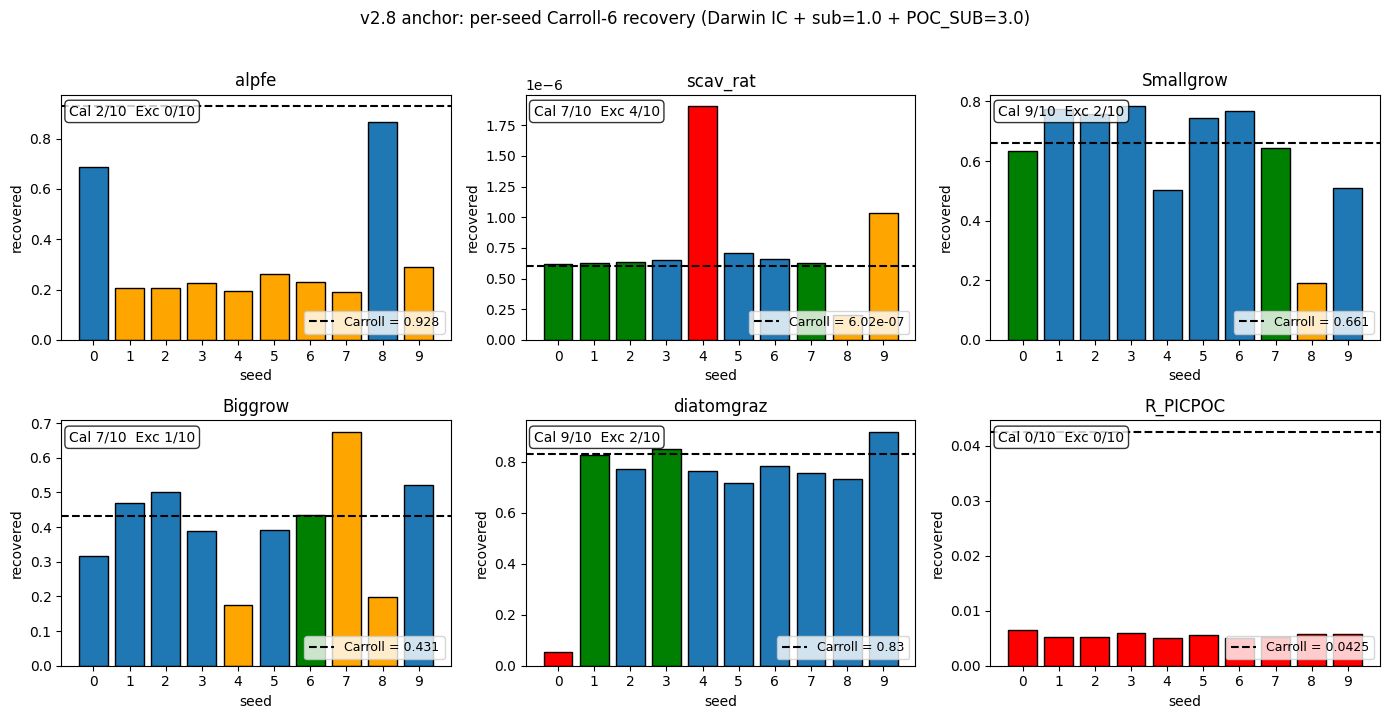

In [6]:
anchor_runs = configs['v2.8: + POC_SUB=3.0 (anchor)']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, p in zip(axes.flat, PARAM_ORDER):
    vals = np.array([r['params'][p]['recovered'] for r in anchor_runs])
    rels = np.array([r['params'][p]['abs_rel_offset'] for r in anchor_runs])
    bands = [r['params'][p]['band'] for r in anchor_runs]
    color_map = {'Excellent': 'green', 'Cal-grade': 'C0', 'Loose': 'orange', 'Drifted': 'red'}
    colors = [color_map[b] for b in bands]
    seeds = list(range(len(vals)))
    ax.bar(seeds, vals, color=colors, edgecolor='black')
    ax.axhline(CARROLL[p], color='k', linestyle='--', linewidth=1.5, label=f"Carroll = {CARROLL[p]:.3g}")
    ax.set_title(f'{p}')
    ax.set_xlabel('seed'); ax.set_ylabel('recovered')
    ax.set_xticks(seeds)
    n_exc = sum(1 for b in bands if b == 'Excellent')
    n_cal = sum(1 for b in bands if b in ('Excellent', 'Cal-grade'))
    ax.text(0.02, 0.96, f'Cal {n_cal}/10  Exc {n_exc}/10', transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.legend(loc='lower right', fontsize=9)
plt.suptitle('v2.8 anchor: per-seed Carroll-6 recovery (Darwin IC + sub=1.0 + POC_SUB=3.0)', y=1.02)
plt.tight_layout(); plt.show()


## 6. Seed 0 — the closest single seed to "all-Cal-grade"

Seed 0 at the anchor reaches `alpfe + scav_rat + Smallgrow + Biggrow` all Cal-grade or better simultaneously. First time in the project.


In [7]:
seed0 = [r for r in anchor_runs if r['seed'] == 0][0]
rows = []
for p in PARAM_ORDER:
    pdata = seed0['params'][p]
    rows.append({
        'param': p,
        'recovered': pdata['recovered'],
        'carroll': CARROLL[p],
        'rel_off': pdata['abs_rel_offset'],
        'band': pdata['band'],
    })
import pandas as pd
seed0_df = pd.DataFrame(rows)
seed0_df['recovered'] = seed0_df['recovered'].apply(lambda v: f'{v:.4g}')
seed0_df['carroll'] = seed0_df['carroll'].apply(lambda v: f'{v:.4g}')
seed0_df['rel_off'] = seed0_df['rel_off'].apply(lambda v: f'{v:.3f}')
print(f'Seed 0 reached {seed0["n_cal_grade"]}/6 Cal-grade with {seed0["n_excellent"]} Excellent.')
seed0_df


Seed 0 reached 4/6 Cal-grade with 2 Excellent.


,param,recovered,carroll,rel_off,band
0,alpfe,0.6859,0.9283,0.261,Cal-grade
1,scav_rat,6.179e-07,6.025e-07,0.026,Excellent
2,Smallgrow,0.6342,0.661,0.040,Excellent
3,Biggrow,0.3161,0.4315,0.267,Cal-grade
4,diatomgraz,0.05396,0.83,0.935,Drifted
5,R_PICPOC,0.006508,0.04245,0.847,Drifted


## 7. Discussion

Three things this analysis surfaces:

1. **`scav_rat` is recoverable** under the right combination of ICs + observational anchor. Across 100+ prior v2.6/v2.7 experiments it stuck at ~0.91 off Carroll; v2.8 produces 4 seeds at Excellent.
2. **The recovery is basin-selective.** `POC_SUB_W` doesn't smoothly improve recovery; it switches the optimizer between two qualitatively distinct local minima of the loss surface. Carroll's *joint* `(alpfe, scav_rat)` calibration is at neither basin — it's identifiability-blocked under our current 6-param / 11-target structure.
3. **What v2.8 doesn't move**: `R_PICPOC` stays at 0/10 Cal-grade across every weight tested. The structural argument from v2.6 stands — PIC observations remain the next required unblock.

## Next steps

- **v3.0 multi-AOI** (PR #44 design merged): test whether cross-regime training (Eq Pac + N Atlantic subpolar + Southern Ocean Pacific) collapses the bimodal degeneracy. Hypothesis: an iron-replete regime forces alpfe and scav_rat to satisfy *different* constraints simultaneously, narrowing the loss surface to a single minimum.
- **Block-CV check on seed 0**: validate that the "alpfe + scav_rat both Cal-grade" result holds under spatial extrapolation (west 2/3 train, east 1/3 test).
- **GEOTRACES POC swap**: replace the Darwin self-target POC with real GEOTRACES `POC_LPT_CONC + POC_SPT_CONC`. Methodological consistency improvement.
- **PIC observations**: separate loader effort to unblock `R_PICPOC`.

See [`docs/findings/v2.8_darwin_ic_poc_sub.md`](../docs/findings/v2.8_darwin_ic_poc_sub.md) for the full writeup including the mechanism (30× too-high literature surface FeT, 8× too-low subsurface POC).
